# ___Summary of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("ggplot2")
})

In [3]:
packageVersion("OUwie")

[1] '3.2'

In [4]:
packageVersion("corHMM")

[1] '2.8'

In [1]:
#--------------------------
# helper functions
#--------------------------

read_all_rds <- function(dirpath, cd, strip, rm_underscores = TRUE) {
    # dirpath = path to the directory containing the .Rds files
    # cd = character dependent or independent models, these are expected to contain "CD" or "CID" in their names
    # strip = the regex pattern to strip out of the file names when naming objects, can be a plain string as well
    # rm_underscores - strip all the underscores in the object name

    fnames <- list.files(dirpath) # all the files in the specified dir
    if(cd) fnames <- fnames[grep(pattern = "CD", fnames)]
    else fnames <- fnames[grep(pattern = "CID", fnames)] # cherry pick CD or CID models, given their names contain "CD" or "CID" to distinguish them
    # print(fnames)

    paths <- paste0(dirpath, fnames) # relative paths for all the Rds files
    stopifnot(length(fnames)==length(paths))

    # remove the unnecessary parts of the file names to create the model names and also remove all the underscores
    mnames <- fnames |> gsub(pattern = ".Rds", replacement = '') |> gsub(pattern = strip, replacement = '') |> gsub(pattern = ifelse(rm_underscores, '_', ''), replacement = '')
    stopifnot(length(fnames)==length(mnames))
    stopifnot(length(paths)==length(mnames))

    models <- list()
    for (i in seq_along(mnames)) models[[mnames[i]]] <- readRDS(file = paths[i])
    stopifnot(length(models)==length(mnames))

    models
}


convergence_failures <- function(models, strip='', threshold_diff_aicc=1e5){
    model_table <- OUwie::getModelTable(models, type = "AICc") # model table from the models
    model_names <- row.names(model_table)
    model_names <- gsub(pattern = strip, replacement = '', x = model_names) # strip off the specified pattern from the names
    aiccs <- model_table[, "AICc"] # this becomes a hard requirement of the function, that the input dataframe needs to have a column named "AICc"
    # so the criteria is that the absoulte difference between the AICc of a given model and the highest AICc (worst fit) shouldn't exceed 1e5, else it's considered a convergence failure
    model_names[abs(aiccs - max(aiccs)) >= threshold_diff_aicc]  # with an option provided to pass in a custom difference threshold
}

plot_model_averages <- function(data){
    # the data argument is expected to be the untouched output of the OUwie::getModelAvgParams() function
    stopifnot(is.data.frame(data))
    
    options(repr.plot.width = 15, repr.plot.height = 15)
    par(mfrow = c(2, 2), mar = c(3, 4, 0, 0), mgp = c(2.25, 0.75, 0))

    boxplot(formula = rates ~ tip_state, data = data, xlab = NULL, ylab = "Rates")
    boxplot(formula = alpha ~ tip_state, data = data, xlab = NULL, ylab = expression(alpha))
    boxplot(formula = sigma.sq ~ tip_state, data = data, xlab = NULL, ylab = expression(sigma^2))
    boxplot(formula = theta ~ tip_state, data = data, xlab = NULL, ylab = expression(theta))
}

In [6]:
# find out the AIC and AICc of all the models

# OUwie::getModelAvgParams()
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

# look up to see what the BIC stuff is about https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

## ___1. 995 species, 5 mycorrhizal states and FRED 3.0___
------------------------------

In [3]:
#---------------
# root diameter
#---------------

rd_995_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = TRUE, strip = "F00679_CD")
rd_995_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = FALSE, strip = "F00679_CID")

In [11]:
OUwie::getModelTable(rd_995_cd)

,np,lnLik,DiscLik,ContLik,BIC,dBIC,BICwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-837.7815,-222.4381,-610.7957,1861.937,62.31878,2.935049e-14
ARDOUMA,31,-1240.7399,-224.6911,-1009.8106,2695.465,895.84650,2.946939e-195
ARDOUMV,31,-875.8786,-222.4858,-648.7782,1965.742,166.12397,8.445121e-37
ARDOUMVA,35,-1214.4508,-225.2339,-984.6957,2670.498,870.87929,7.779134e-190
EROUM,8,-1307.4927,-235.9841,-1065.8242,2670.207,870.58908,8.993968e-190
EROUMA,12,-1254.1331,-235.9806,-1017.0206,2591.099,791.48083,1.355464e-172
EROUMV,12,-1238.7481,-235.9414,-999.0268,2560.329,760.71086,6.511823e-166
EROUMVA,16,-1221.0799,-235.9916,-980.3370,2552.604,752.98554,3.099098e-164
SYMOUM,17,-841.1358,-225.8393,-610.8337,1799.618,0.00000,9.999242e-01


In [8]:
convergence_failures(models = rd_995_cd)

character(0)

In [5]:
OUwie::getModelTable(rd_995_cid)

,np,lnLik,DiscLik,ContLik,BIC,dBIC,BICwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-8.660587e+02,-244.8339,-6.175052e+02,2.049644e+03,18253609749,0
ARDOUMA,47,-1.297129e+03,-245.0929,-1.054712e+03,2.918687e+03,18253610618,0
ARDOUMV,47,-1.285349e+03,-244.7591,-1.039078e+03,2.895127e+03,18253610594,0
ARDOUMVA,48,-1.277052e+03,-245.2749,-1.044505e+03,2.885435e+03,18253610584,0
EROUM,8,-8.584728e+02,-236.2650,-6.178687e+02,1.772167e+03,18253609471,0
EROUMA,9,4.294540e+09,-236.6196,-8.320778e+03,-8.589080e+09,9664527207,0
EROUMV,9,-8.728444e+02,-236.0431,-6.322679e+02,1.807814e+03,18253609507,0
EROUMVA,10,9.126804e+09,-242.6438,8.589933e+09,-1.825361e+10,0,1
SYMOUM,26,-8.853430e+02,-248.2156,-1.078624e+03,1.950157e+03,18253609649,0


In [4]:
convergence_failures(models = rd_995_cid) # two failed CID fits

[1] "EROUMA"  "EROUMVA"

In [6]:
capture.output(avg_rd_995_cd <- OUwie::getModelAvgParams(rd_995_cd, type = "AICc", force = FALSE), file = nullfile()) # OUwie::getModelAvgParams spits out a lot of stuff, we don't want that here
capture.output(avg_rd_995_cid <- OUwie::getModelAvgParams(rd_995_cid, type = "AICc", force = FALSE), file = nullfile())

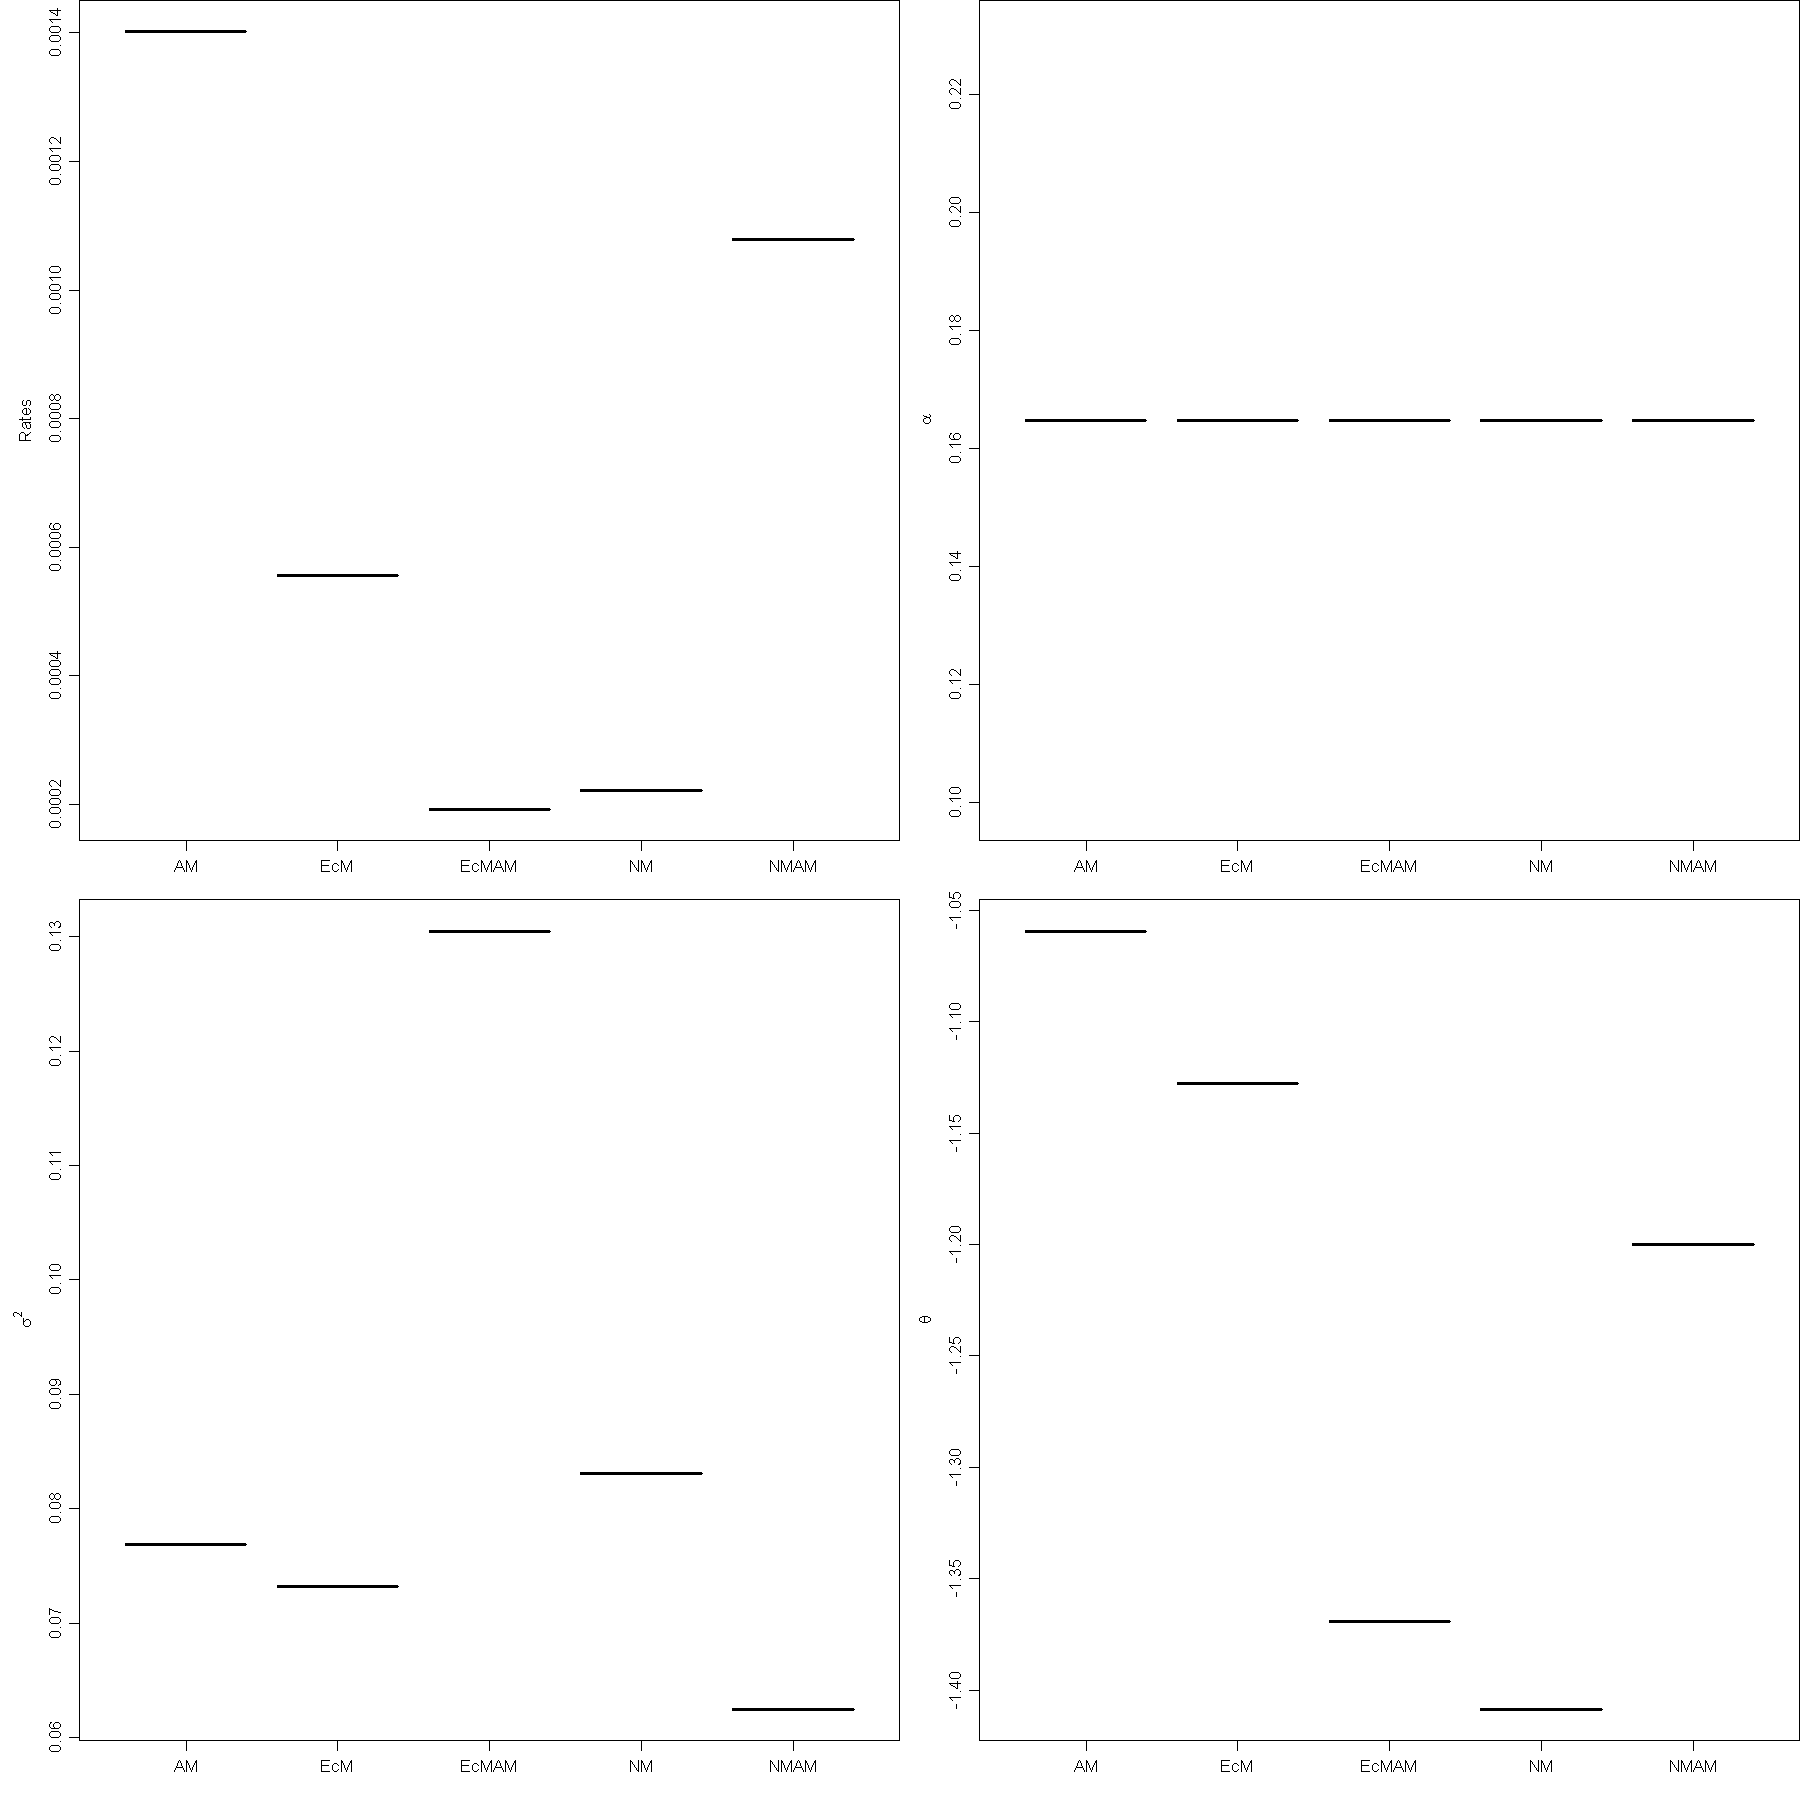

In [7]:
plot_model_averages(data = avg_rd_995_cd) # CD fits

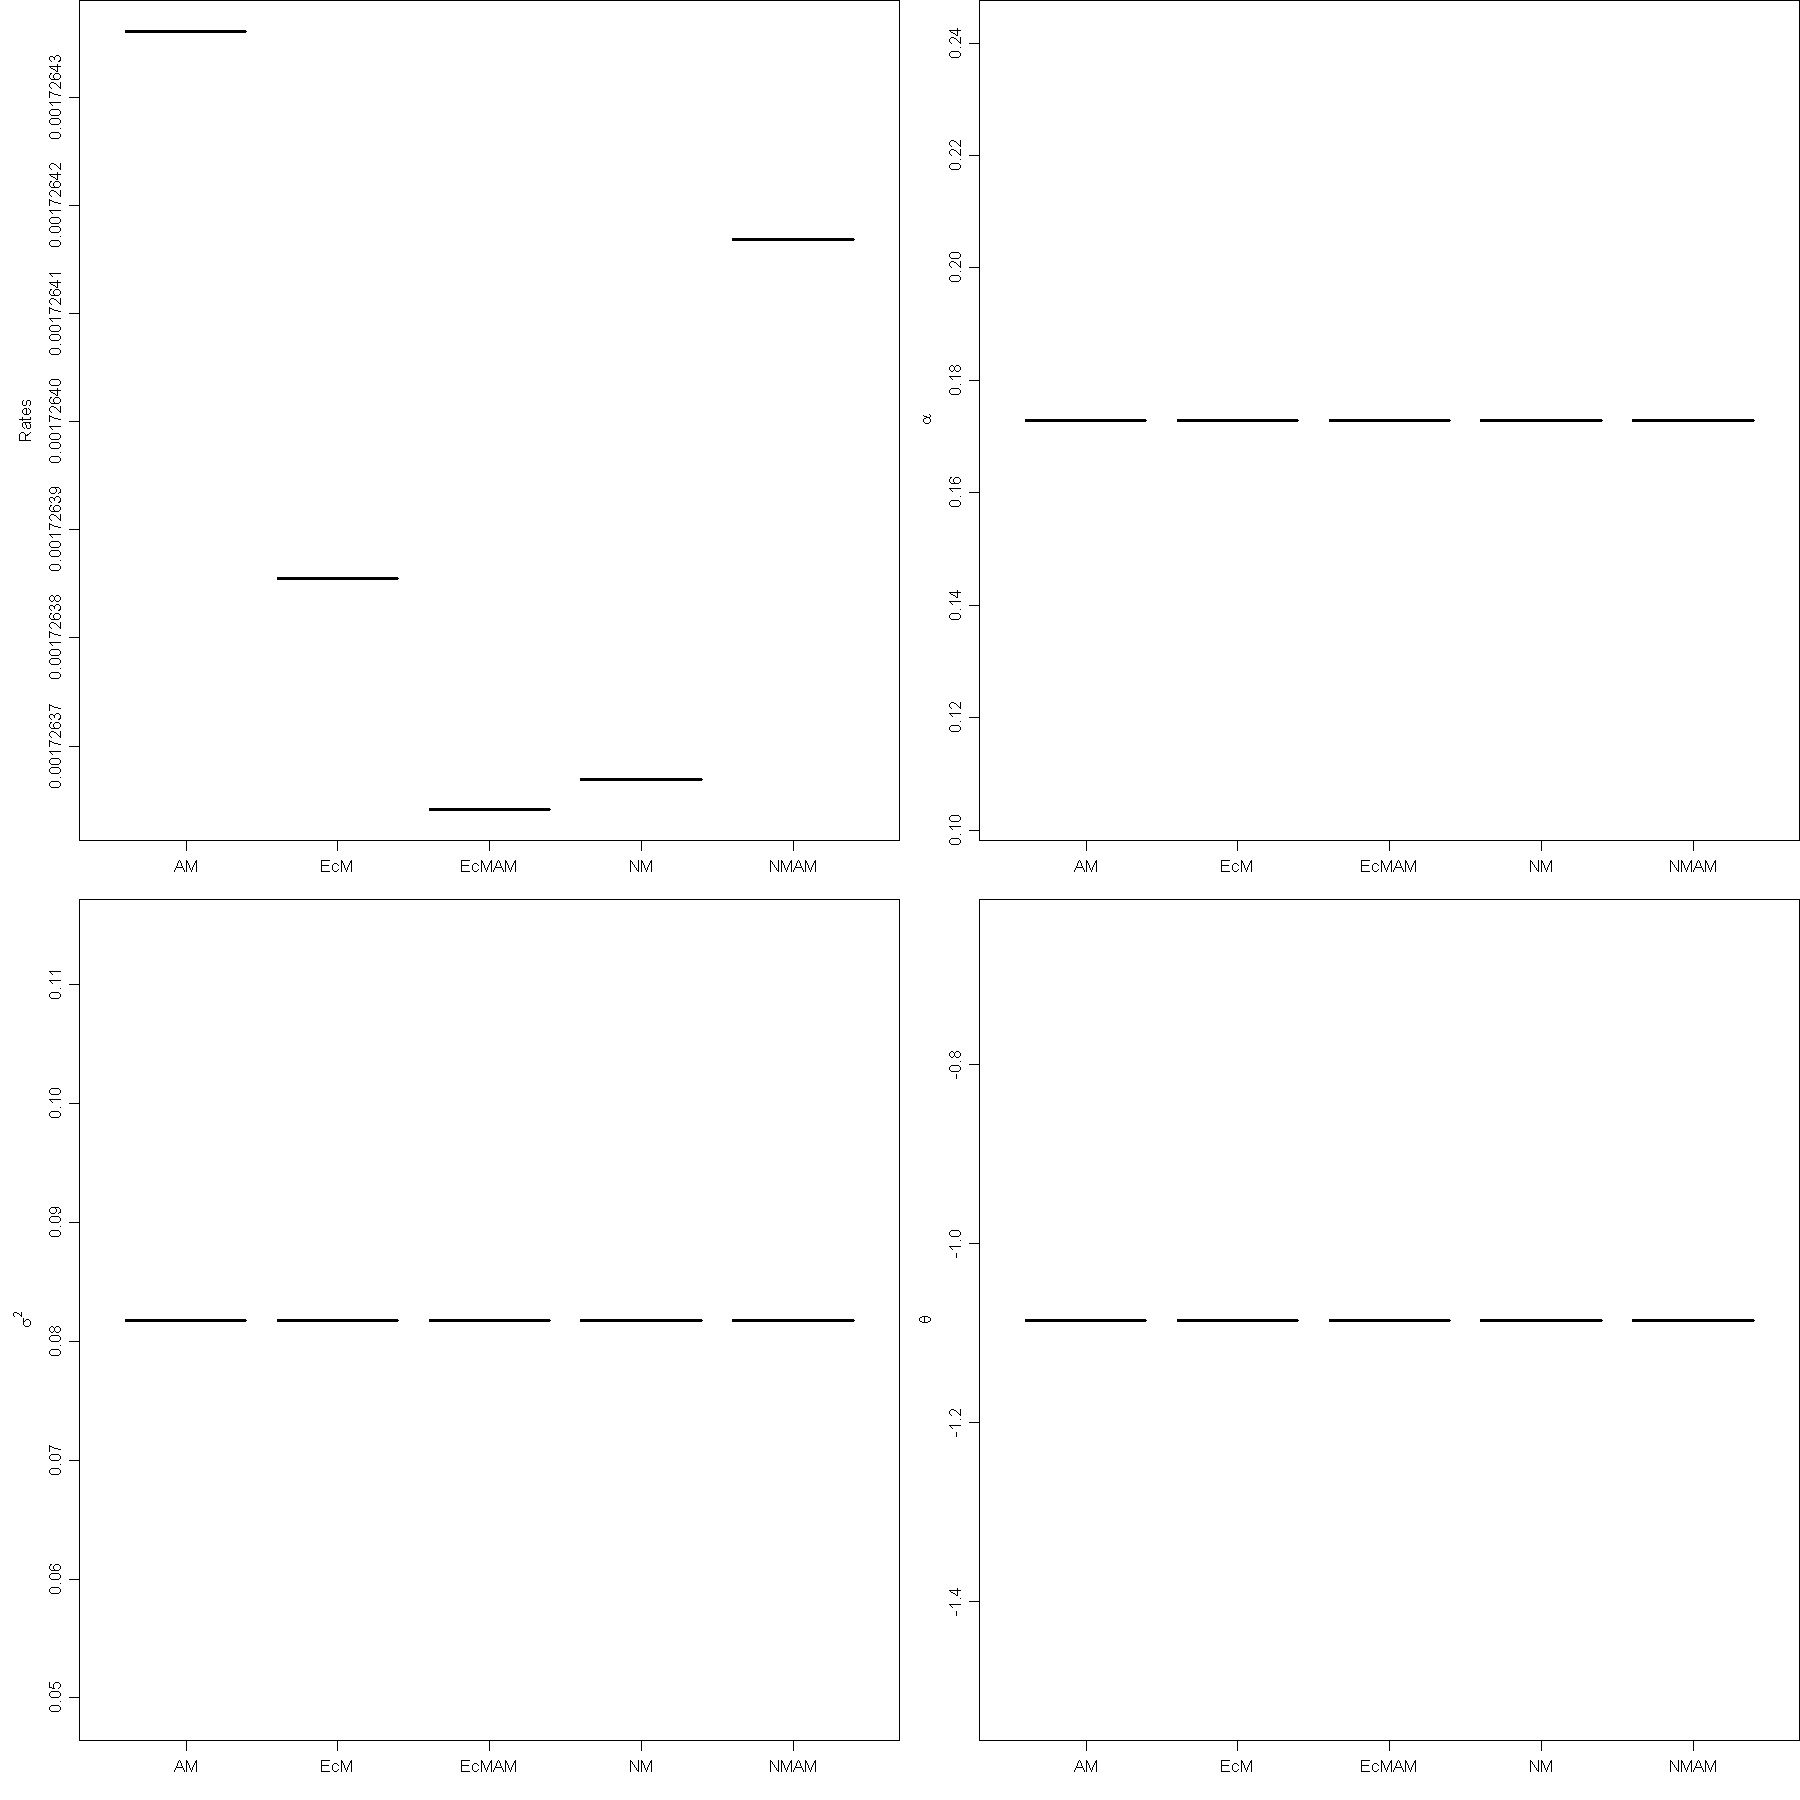

In [8]:
plot_model_averages(data = avg_rd_995_cid) # CID fits

In [9]:
#------------------------
# specific root length
#------------------------

srl_995_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = TRUE, strip = "F00727_CD")
srl_995_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = FALSE, strip = "F00727_CID")

In [10]:
OUwie::getModelTable(srl_995_cd)

,np,lnLik,DiscLik,ContLik,BIC,dBIC,BICwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-1898.815,-222.4386,-1671.813,3984.004,119.81431,9.605239e-27
ARDOUMA,31,-2211.673,-224.2157,-1983.303,4637.331,773.14068,1.301636e-168
ARDOUMV,31,-2221.894,-222.3920,-1995.005,4657.773,793.58289,4.737182e-173
ARDOUMVA,35,-2164.539,-225.2221,-1934.445,4570.673,706.48333,3.881058e-154
EROUM,8,-1904.484,-235.9440,-1664.636,3864.190,0.00000,9.996672e-01
EROUMA,12,-2234.623,-235.9917,-1992.989,4552.080,687.88971,4.231577e-150
EROUMV,12,-1898.686,-235.9516,-1658.743,3880.205,16.01529,3.327976e-04
EROUMVA,16,-2198.069,-236.0035,-1958.364,4506.582,642.39195,3.207861e-140
SYMOUM,17,-1894.319,-225.8475,-1664.442,3905.984,41.79372,8.403579e-10


In [11]:
convergence_failures(srl_995_cd)

character(0)

In [12]:
OUwie::getModelTable(srl_995_cid)

,np,lnLik,DiscLik,ContLik,BIC,dBIC,BICwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,46,-2.280617e+03,-265.4901,-2025.149,4.878760e+03,17179870229,0
ARDOUMA,47,-2.174983e+03,-262.8171,-2053.463,4.674396e+03,17179870024,0
ARDOUMV,47,-2.249811e+03,-260.8590,-2026.660,4.824051e+03,17179870174,0
ARDOUMVA,48,-2.085369e+03,-268.5176,-1833.000,4.502070e+03,17179869852,0
EROUM,8,-2.265167e+03,-235.9243,-2024.658,4.585556e+03,17179869935,0
EROUMA,9,8.589933e+09,-236.3958,536869234.335,-1.717987e+10,0,1
EROUMV,9,-1.913447e+03,-235.9671,-1673.154,3.889019e+03,17179869239,0
EROUMVA,10,-2.144410e+03,-237.5550,-2013.270,4.357848e+03,17179869708,0
SYMOUM,26,-1.919728e+03,-250.2099,-1734.309,4.018927e+03,17179869369,0


In [14]:
convergence_failures(srl_995_cid) # two failures

[1] "EROUMA"  "SYMOUMA"

In [ ]:
avg_srl_995_cd <- OUwie::getModelAvgParams(srl_995_cd, type = "AICc", force = FALSE)
capture.output(avg_srl_995_cid <- OUwie::getModelAvgParams(srl_995_cid, type = "AICc", force = FALSE), file = nullfile())

In [150]:
extract_and_combine_aiccs <- function(model_list_vec, column_names, type="AICc", threshold=1e5){
    stopifnot(length(model_list_vec)==length(column_names)) # make sure each model group receives a unique column name
    akaike <- lapply(model_list_vec, FUN = function(modlist) OUwie::getModelTable(model.list = modlist, type = type)[type]) # capture the model tables in a list
    akaike <- as.data.frame(akaike)
    colnames(akaike) <- column_names # set the new column names
    akaike$model <- rownames(akaike) # capture the row names as a new column
    rownames(akaike) <- NULL # remove the row names
                     
    for (c in column_names) akaike[abs(max(akaike[, c]) - akaike[, c]) >= threshold, c] <- NA
    akaike
}

In [151]:
summary_aiccs <- extract_and_combine_aiccs(list(rd_cd, rd_cid, srl_cd, srl_cid), c("RDcd", "RDcid", "SRLcd", "SRLcid"))
write.csv(x = summary_aiccs, file = "../../data/chapter2/hOUwie_aicc_model_tables_995sp_100sims.csv", row.names = FALSE)

In [ ]:
# compute the average of all the model groups

modavg_rd_cd <- OUwie::getModelAvgParams(rd_cd, type = "AICc", force = FALSE)
modavg_rd_cid <- OUwie::getModelAvgParams(rd_cid, type = "AICc", force = FALSE)
modavg_srl_cd <- OUwie::getModelAvgParams(srl_cd, type = "AICc", force = FALSE)
modavg_srl_cid <- OUwie::getModelAvgParams(srl_cid, type = "AICc", force = FALSE)

In [15]:
# write all the group averages to a single .csv file

write.csv(rbind(
    cbind(modavg_rd_cd, trait = "RD", cd = TRUE), cbind(modavg_rd_cid, trait = "RD", cd = FALSE),
    cbind(modavg_srl_cd, trait = "SRL", cd = TRUE), cbind(modavg_srl_cid, trait = "SRL", cd = FALSE)
), file = "../../data/chapter2/hOUwie_summary_995sp_100sims.csv")

In [16]:
OUwie::getModelTable(rd_cid, type = "AICc")["AICc"]

,AICc
,<dbl>
ARDOUM,1.828679e+03
ARDOUMA,2.693023e+03
ARDOUMV,2.669462e+03
ARDOUMVA,2.655076e+03
EROUM,1.733092e+03
EROUMA,-8.589081e+09
EROUMV,1.763872e+03
EROUMVA,-1.825361e+10
SYMOUM,1.824136e+03


In [17]:
# get all the AICcs in one table

summary_aicc <- rbind(
    cbind(OUwie::getModelTable(rd_cd, type = "AICc")["AICc"], trait = "RD", cd = TRUE),
    cbind(OUwie::getModelTable(rd_cid, type = "AICc")["AICc"], trait = "RD", cd = FALSE),
    cbind(OUwie::getModelTable(srl_cd, type = "AICc")["AICc"], trait = "SRL", cd = TRUE),
    cbind(OUwie::getModelTable(srl_cid, type = "AICc")["AICc"], trait = "SRL", cd = FALSE)
)

In [26]:
head(summary_aicc)

,AICc,trait,cd
,<dbl>,<chr>,<lgl>
ARDOUM,1731.127,RD,TRUE
ARDOUMA,2545.540,RD,TRUE
ARDOUMV,1815.817,RD,TRUE
ARDOUMVA,2501.529,RD,TRUE
EROUM,2631.131,RD,TRUE
EROUMA,2532.584,RD,TRUE


In [27]:
summary_aicc["models"] <- summary_aicc |> rownames() |> gsub(pattern = "\\d{1}$", # remove the numbers appended to the names of duplicate rows
                                   replacement = '')
rownames(summary_aicc) <- NULL # drop the original row names
write.csv(summary_aicc, file="../../data/chapter2/hOUwie_aicc_summary_all_995sp_100sims.csv", row.names=FALSE)

In [15]:
# root diameter (RD) 1301 species
rd_cd <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = TRUE, regstrip = "F00679_CD.Rds") # 12 models
rd_cid <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = FALSE, regstrip = "F00679_CID.Rds") # 12 models

In [18]:
failed_convergence(OUwie::getModelTable(rd_cd, type = "AICc"))

[1] "ARDOUMA"  "EROUMA"   "EROUMVA"  "SYMOUMA"  "SYMOUMVA"

In [19]:
failed_convergence(OUwie::getModelTable(rd_cid, type = "AICc"))

[1] "ARDOUMA"  "ARDOUMVA" "EROUMA"   "SYMOUMA"  "SYMOUMVA"

In [20]:
OUwie::getModelTable(rd_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,38,-169625.07,-210.3268,-169406.23,339328.48,301902.03,0
ARDOUMA,43,-27256.80,-227.7743,-37303.47,54602.62,17176.17,0
ARDOUMV,43,-170810.75,-217.6320,-170584.97,341710.51,304284.05,0
ARDOUMVA,48,-186164.82,-227.7870,-5945873.94,372429.41,335002.95,0
EROUM,9,-162911.54,-226.1279,-162677.74,325841.21,288414.76,0
EROUMA,14,-18699.06,-4217.0130,-63987.08,37426.45,0.00,1
EROUMV,14,-163286.96,-225.8778,-163056.57,326602.24,289175.79,0
EROUMVA,19,-48617.21,-1323.5316,-75649.06,97273.01,59846.55,0
SYMOUM,23,-167072.63,-222.9057,-174459.32,334192.13,296765.68,0


In [21]:
OUwie::getModelTable(rd_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,66,-125054.19,-258.2815,-133348.54,250247.54,190689.446,0
ARDOUMA,67,-40569.09,-256.2116,-52504.70,81279.57,21721.478,0
ARDOUMV,67,-170910.20,-255.6526,-170702.97,341961.78,282403.687,0
ARDOUMVA,68,-31942.45,-258.2381,-60490.74,64028.52,4470.423,0
EROUM,8,-132590.66,-230.1963,-175342.03,265197.43,205639.328,0
EROUMA,9,-111869.79,-518.4454,-118569.32,223757.72,164199.622,0
EROUMV,9,-124656.54,-320.0560,-133164.15,249331.21,189773.114,0
EROUMVA,10,-136924.07,-244.2835,-144052.83,273868.31,214310.212,0
SYMOUM,36,-124243.17,-249.1996,-130398.55,248560.44,189002.347,0


In [23]:
# root diameter (RD) 1292 species
rd_cd <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1292_100sims/", cd = TRUE, regstrip = "F00679_CD.Rds") # 12 models
rd_cid <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/rd_1292_100sims/", cd = FALSE, regstrip = "F00679_CID.Rds") # 12 models

In [28]:
OUwie::getModelTable(rd_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,27,-123255.19,-199.9815,-123051.35,246565.58,171311.57,0
ARDOUMA,31,-37595.22,-212.9464,-85496.09,75254.01,0.00,1
ARDOUMV,31,-123200.67,-201.5091,-122994.18,246464.92,171210.91,0
ARDOUMVA,35,-75886.77,-213.1033,-119266.61,151845.54,76591.53,0
EROUM,8,-84491.61,-214.8045,-84269.55,168999.34,93745.33,0
EROUMA,12,-56168.96,-312.9568,-62871.31,112362.17,37108.16,0
EROUMV,12,-84469.78,-213.2868,-88710.85,168963.80,93709.79,0
EROUMVA,16,-138386.88,-290.6309,-262661.63,276806.18,201552.17,0
SYMOUM,17,-83659.46,-228.0067,-84604.96,167353.40,92099.39,0


In [24]:
failed_convergence(OUwie::getModelTable(rd_cd, type = "AICc"))

[1] "ARDOUMA"  "ARDOUMVA" "EROUM"    "EROUMA"   "EROUMV"   "SYMOUM"   "SYMOUMA" 
[8] "SYMOUMV"  "SYMOUMVA"

In [25]:
failed_convergence(OUwie::getModelTable(rd_cid, type = "AICc"))

[1] "ARDOUMA"  "ARDOUMVA" "EROUMA"   "EROUMVA"  "SYMOUMA"  "SYMOUMVA"